# Tiny Graphs - Transformer (Self-Edge Ablation)

Each graph section is self-contained and can be run independently: config -> train/load -> evaluation -> embeddings/edges -> reduction -> raw plot -> styled plot -> evolution -> heatmap -> line plot.


## 1) Tiny Path-Star (deg=4, deg_tree=1, path_len=5)


In [1]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_laplacian_coordinates,
    compute_spectral_bias_from_state,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_spectral_bias,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [2]:
path_star_seed = 7

path_star_train_from_scratch = False
path_star_checkpoint_path = ""
path_star_embedding_history_path = ""
path_star_topk_history_path = ""
path_star_dataset_overwrite = False

path_star_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.01,
    "--edge_memorization_epochs": 500,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0.0,
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0.,

    "--graph_type": "star",
    "--star_degree": 4,
    "--star_subtree_degree": 1,
    "--path_length": 5,
    "--total_nodes": -1,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": True,
}


In [3]:
path_star_context = build_transformer_section_context(
    path_star_cli_config,
    seed=path_star_seed,
    dataset_overwrite=path_star_dataset_overwrite,
)

path_star_resolved_checkpoint_path = train_or_load_edge_model(
    path_star_context,
    train_from_scratch=path_star_train_from_scratch,
    checkpoint_path=path_star_checkpoint_path,
)

print("Run name:", path_star_context.args.run_name)
print("Checkpoint:", path_star_resolved_checkpoint_path)
print("Pretrain file:", path_star_context.pretrain_path)
print("Train file:", path_star_context.train_path)
print("Test file:", path_star_context.test_path)
print("Archived checkpoint:", path_star_context.checkpoint_path)
print("Embedding history pickle:", path_star_context.embedding_history_path)
print("Top-k pickle:", path_star_context.topk_history_path)
print("Manifest:", path_star_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_selfedge_0_train_3.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_selfedge_0_test_1.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_

In [4]:
path_star_eval_metrics = evaluate_edge_and_path(path_star_context)

print_evaluation_report("Tiny Path-Star", path_star_eval_metrics)


Edge Memorization | Loss: 1.0253 | Acc: 51.52%: 100%|██████████| 1/1 [00:00<00:00,  2.07it/s]


Edge Memorization | Loss: 1.0253 | Acc: 51.52%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 58.26it/s]

Tiny Path-Star | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [5]:
path_star_node_embeddings, path_star_edge_list, path_star_root_node_index = collect_embeddings_and_edges(path_star_context)

path_star_embedding_history, path_star_topk_recovery_history = load_analysis_histories(
    path_star_context,
    path_star_edge_list,
    embedding_history_path=path_star_embedding_history_path,
    topk_history_path=path_star_topk_history_path,
)

if not path_star_embedding_history:
    path_star_embedding_history = {0: path_star_node_embeddings}
if not path_star_topk_recovery_history:
    path_star_topk_recovery_history = {0: path_star_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", path_star_node_embeddings.shape)
print("Number of edges:", len(path_star_edge_list))
print("Root node index:", path_star_root_node_index)
print("Embedding history steps:", len(path_star_embedding_history))
print("Top-k history steps:", len(path_star_topk_recovery_history))


Node embedding shape: (17, 32)
Number of edges: 66
Root node index: 3
Embedding history steps: 500
Top-k history steps: 500


In [6]:
# Reduction config for this block (kept local to reduction stage)
path_star_use_umap = False
path_star_reduction_dim = 4
path_star_umap_n_neighbors = 5
path_star_umap_min_dist = 0.3

path_star_reduced_full, path_star_reduced_embeddings = reduce_embeddings_for_plot(
    path_star_node_embeddings,
    use_umap=path_star_use_umap,
    reduction_dim=path_star_reduction_dim,
    seed=path_star_seed,
    umap_n_neighbors=path_star_umap_n_neighbors,
    umap_min_dist=path_star_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
path_star_reduced_embeddings = path_star_reduced_full[:, :3]
print("Reduced full shape:", path_star_reduced_full.shape)
print("Reduced xyz shape:", path_star_reduced_embeddings.shape)


Reduced full shape: (17, 4)
Reduced xyz shape: (17, 3)


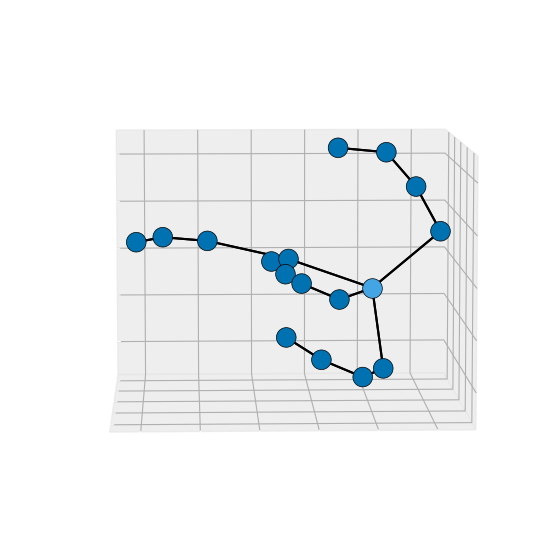

In [7]:
# %matplotlib widget
%matplotlib inline

path_star_raw_elev = 7
path_star_raw_azim = 88
path_star_raw_roll = 0

# Styled plotting constants for this block
path_star_styled_view = {"elev": path_star_raw_elev, "azim": path_star_raw_azim, "roll": path_star_raw_roll}
path_star_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    path_star_reduced_embeddings,
    path_star_edge_list,
    title="",
    view=path_star_styled_view,
    root_node_index=path_star_root_node_index,
    axis_permutation=path_star_styled_axis_permutation,
);


Requested evolution steps: [0, 100, 500]
Resolved evolution steps: [0, 100, 499]


/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/analysis/analysis_plots.py:139: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


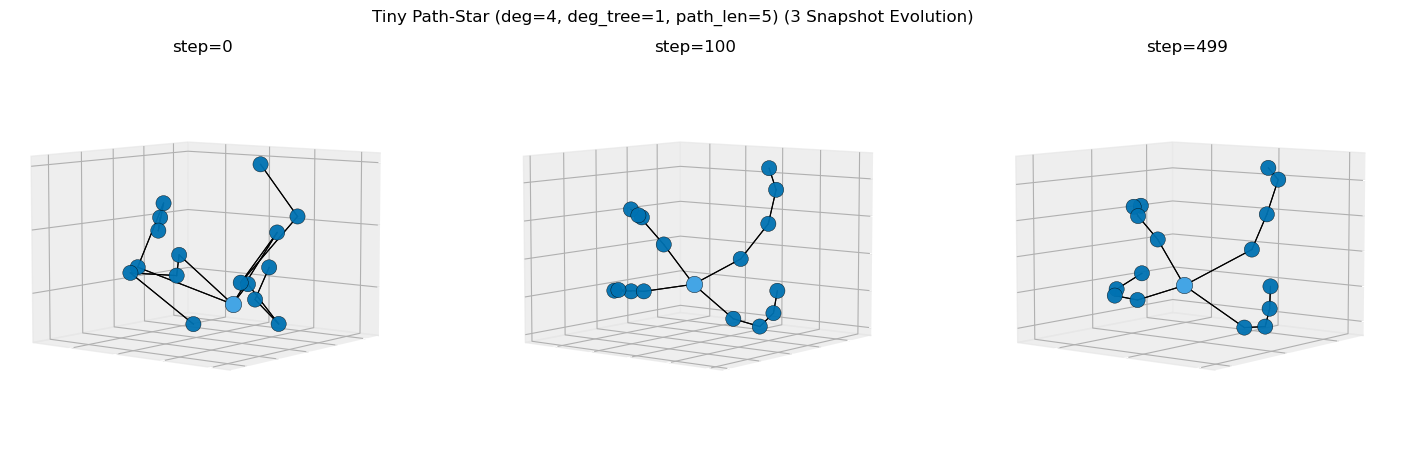

In [8]:
# Evolution constants for this block
path_star_evolution_steps = [0, 100, 500]
path_star_evolution_use_umap = False
path_star_evolution_reduction_dim = 3
path_star_evolution_umap_n_neighbors = 2
path_star_evolution_umap_min_dist = 0.3
path_star_evolution_view = {"elev": path_star_raw_elev, "azim": path_star_raw_azim+40, "roll": path_star_raw_roll}
path_star_evolution_axis_permutation = (0, 1, 2)

path_star_resolved_evolution_steps, path_star_reduced_evolution = build_reduced_evolution_snapshots(
    path_star_embedding_history,
    selected_steps=path_star_evolution_steps,
    use_umap=path_star_evolution_use_umap,
    reduction_dim=path_star_evolution_reduction_dim,
    seed=path_star_seed,
    umap_n_neighbors=path_star_evolution_umap_n_neighbors,
    umap_min_dist=path_star_evolution_umap_min_dist,
)

print("Requested evolution steps:", path_star_evolution_steps)
print("Resolved evolution steps:", path_star_resolved_evolution_steps)

plot_three_snapshot_evolution(
    path_star_reduced_evolution,
    path_star_edge_list,
    title="Tiny Path-Star (deg=4, deg_tree=1, path_len=5) (3 Snapshot Evolution)",
    view=path_star_evolution_view,
    axis_permutation=path_star_evolution_axis_permutation,
    root_node_index=path_star_root_node_index,
);


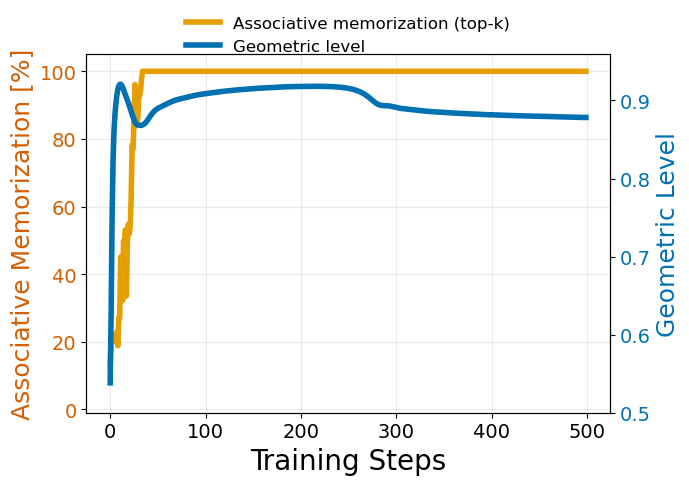

In [9]:
# Line-plot constants for this block
path_star_line_plot_title = ""

path_star_curve_steps, path_star_curve_associative, path_star_curve_geometric = compute_associative_geometric_curves(
    path_star_embedding_history,
    path_star_topk_recovery_history,
    path_star_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=path_star_curve_steps,
    associative_scores=path_star_curve_associative,
    geometric_scores=path_star_curve_geometric,
    title=path_star_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `path_star_heatmap_epoch` to one of the highest geometric_level epochs.

Path-star heatmap epoch: 100
Path-star branch layout:
3 2 13 14 7
3 9 15 12 5
3 11 8 1 0
3 16 6 4 10
Path-star heatmap order: [3, 2, 13, 14, 7, 9, 15, 12, 5, 11, 8, 1, 0, 16, 6, 4, 10]


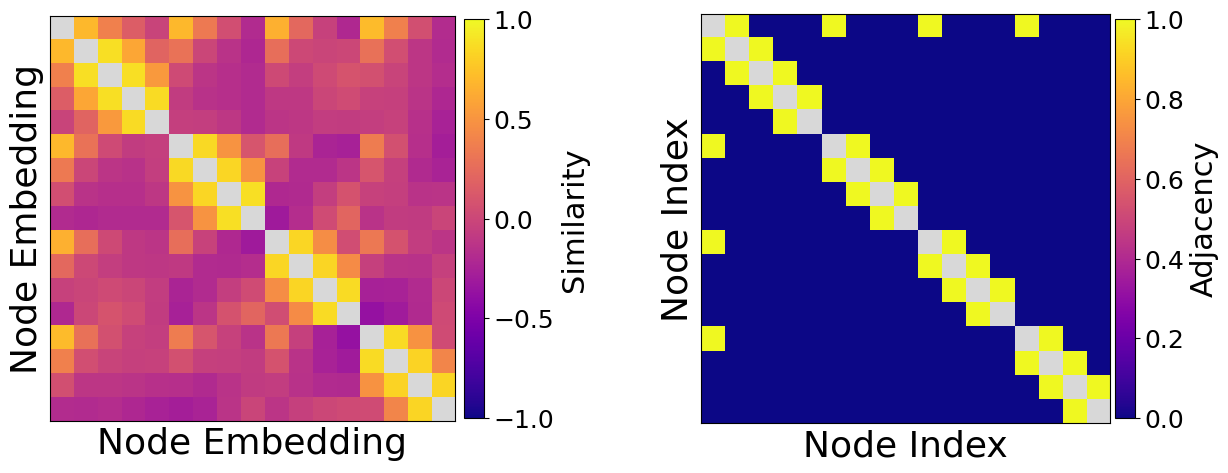

In [10]:
# Heatmap constants for this block
path_star_heatmap_graph_type = path_star_context.args.graph_type
path_star_heatmap_epoch = 100
path_star_heatmap_cmap_name = "plasma"
path_star_heatmap_wspace = 0.5

path_star_heatmap_embeddings, path_star_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=path_star_embedding_history,
    fallback_embeddings=path_star_node_embeddings,
    requested_step=path_star_heatmap_epoch,
)
print("Path-star heatmap epoch:", path_star_heatmap_resolved_epoch)
path_star_branch_layout = get_star_branch_layout(
    edge_list=path_star_edge_list,
    node_count=path_star_heatmap_embeddings.shape[0],
    root_node_index=path_star_root_node_index,
)
print("Path-star branch layout:")
for branch_row in path_star_branch_layout:
    print(" ".join(str(node_id) for node_id in branch_row))
if path_star_branch_layout:
    path_star_heatmap_order = [path_star_branch_layout[0][0]]
    for branch_row in path_star_branch_layout:
        path_star_heatmap_order.extend(branch_row[1:])
else:
    path_star_heatmap_order = list(range(path_star_heatmap_embeddings.shape[0]))
print("Path-star heatmap order:", path_star_heatmap_order)

plot_ordered_heatmaps(
    embeddings=path_star_heatmap_embeddings,
    edge_list=path_star_edge_list,
    graph_type=path_star_heatmap_graph_type,
    root_node_index=path_star_root_node_index,
    custom_order=path_star_heatmap_order,
    cmap_name=path_star_heatmap_cmap_name,
    wspace=path_star_heatmap_wspace,
);

### Skewed Low-Rank Spectral Bias


In [11]:
# Laplacian geometry constants for this block
path_star_laplacian_axis_indices = (-2, -3, -4)
path_star_spectral_state = build_graph_spectral_state(
    edge_list=path_star_edge_list,
    node_count=path_star_node_embeddings.shape[0],
)

Path-Star normalized eigenvalues:
 [ 1.     1.     1.     0.86   0.648  0.648  0.648  0.374  0.146  0.146
  0.146 -0.117 -0.231 -0.231 -0.231 -0.396]


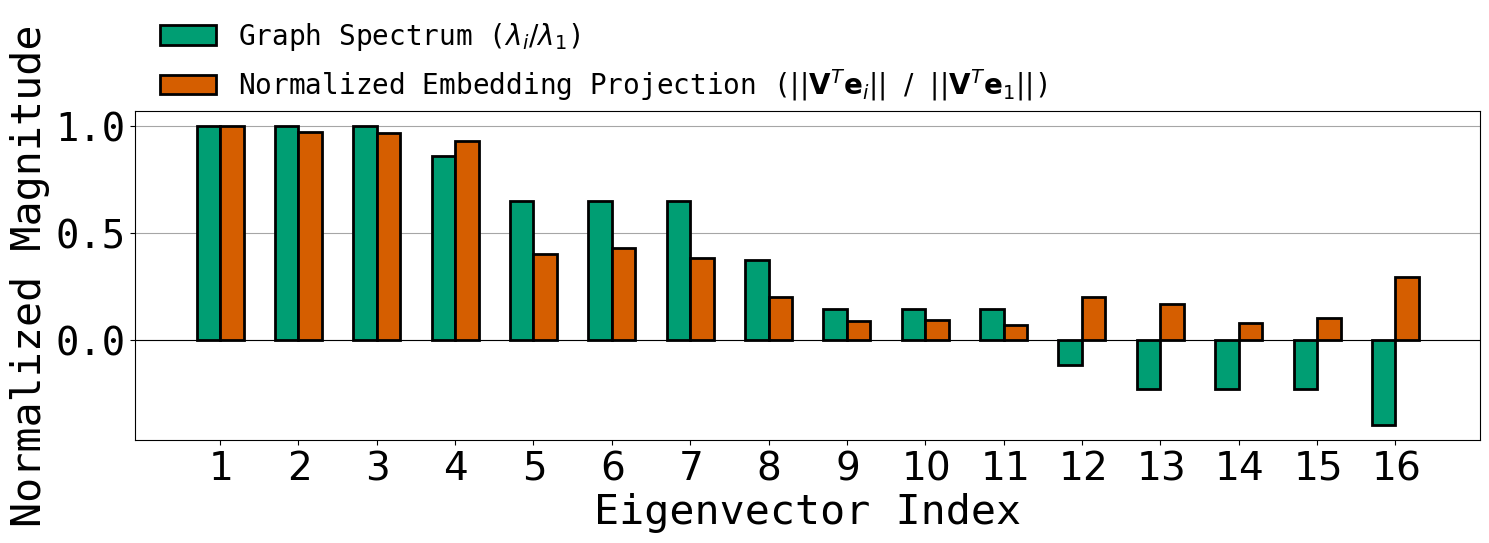

In [12]:
# Spectral-bias constants for this block
path_star_spectral_drop_top_eigenvector = True
path_star_spectral_reorder_prefix = (1, 0, 2)
path_star_spectral_cutoff = None #8
path_star_spectral_figsize = (15.0, 6.0)
path_star_spectral_legend_anchor = (0.0, 1.35)

path_star_norm_eigenvalues, path_star_norm_projections = compute_spectral_bias_from_state(
    embeddings=path_star_node_embeddings,
    spectral_state=path_star_spectral_state,
    drop_top_eigenvector=path_star_spectral_drop_top_eigenvector,
    reorder_prefix=path_star_spectral_reorder_prefix,
)

print("Path-Star normalized eigenvalues:\n", path_star_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=path_star_norm_eigenvalues,
    norm_projections=path_star_norm_projections,
    title="",
    cutoff=path_star_spectral_cutoff,
    figsize=path_star_spectral_figsize,
    ylabel_fontsize=30,
    xlabel_fontsize=30,
    tick_fontsize=28,
    legend_fontsize=20,
    legend_anchor=path_star_spectral_legend_anchor,
    save=True,
    filename=f"{path_star_context.args.graph_type}_{path_star_context.args.model_architecture_label}_eigen_projection"
);


## 2) Tiny Grid (rows=4, cols=4)


In [13]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_laplacian_coordinates,
    compute_spectral_bias_from_state,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_spectral_bias,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [14]:
grid_seed = 7

grid_train_from_scratch = False
grid_checkpoint_path = ""
grid_embedding_history_path = ""
grid_topk_history_path = ""
grid_dataset_overwrite = False

grid_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.01,
    "--edge_memorization_epochs": 500,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0.0,
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0.,

    "--graph_type": "grid",
    "--grid_rows": 4,
    "--grid_cols": 4,
    "--path_length": 5,
    "--total_nodes": -1,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": True,
}


In [15]:
grid_context = build_transformer_section_context(
    grid_cli_config,
    seed=grid_seed,
    dataset_overwrite=grid_dataset_overwrite,
)

grid_resolved_checkpoint_path = train_or_load_edge_model(
    grid_context,
    train_from_scratch=grid_train_from_scratch,
    checkpoint_path=grid_checkpoint_path,
)

print("Run name:", grid_context.args.run_name)
print("Checkpoint:", grid_resolved_checkpoint_path)
print("Pretrain file:", grid_context.pretrain_path)
print("Train file:", grid_context.train_path)
print("Test file:", grid_context.test_path)
print("Archived checkpoint:", grid_context.checkpoint_path)
print("Embedding history pickle:", grid_context.embedding_history_path)
print("Top-k pickle:", grid_context.topk_history_path)
print("Manifest:", grid_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_train_12.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datas

In [16]:
grid_eval_metrics = evaluate_edge_and_path(grid_context)

print_evaluation_report("Tiny Grid", grid_eval_metrics)


Edge Memorization | Loss: 1.4069 | Acc: 25.00%: 100%|██████████| 1/1 [00:00<00:00, 79.46it/s]


Edge Memorization | Loss: 1.4069 | Acc: 25.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 99.72it/s]

Tiny Grid | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [17]:
grid_node_embeddings, grid_edge_list, grid_root_node_index = collect_embeddings_and_edges(grid_context)

grid_embedding_history, grid_topk_recovery_history = load_analysis_histories(
    grid_context,
    grid_edge_list,
    embedding_history_path=grid_embedding_history_path,
    topk_history_path=grid_topk_history_path,
)

if not grid_embedding_history:
    grid_embedding_history = {0: grid_node_embeddings}
if not grid_topk_recovery_history:
    grid_topk_recovery_history = {0: grid_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", grid_node_embeddings.shape)
print("Number of edges:", len(grid_edge_list))
print("Root node index:", grid_root_node_index)
print("Embedding history steps:", len(grid_embedding_history))
print("Top-k history steps:", len(grid_topk_recovery_history))


Node embedding shape: (16, 32)
Number of edges: 64
Root node index: None
Embedding history steps: 500
Top-k history steps: 500


In [18]:
# Reduction config for this block (kept local to reduction stage)
grid_use_umap = False
grid_reduction_dim = 4
grid_umap_n_neighbors = 4
grid_umap_min_dist = 0.3

grid_reduced_full, grid_reduced_embeddings = reduce_embeddings_for_plot(
    grid_node_embeddings,
    use_umap=grid_use_umap,
    reduction_dim=grid_reduction_dim,
    seed=grid_seed,
    umap_n_neighbors=grid_umap_n_neighbors,
    umap_min_dist=grid_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
grid_reduced_embeddings = grid_reduced_full[:, :3]
print("Reduced full shape:", grid_reduced_full.shape)
print("Reduced xyz shape:", grid_reduced_embeddings.shape)


Reduced full shape: (16, 4)
Reduced xyz shape: (16, 3)


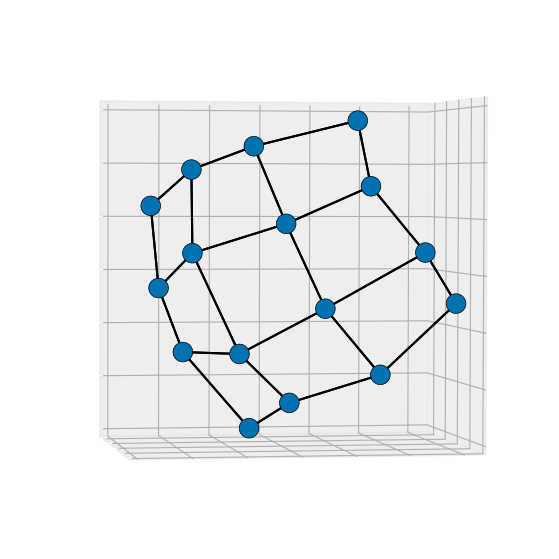

In [19]:
%matplotlib inline
# %matplotlib widget

grid_raw_elev = 80
grid_raw_azim = -10
grid_raw_roll = -100

# Styled plotting constants for this block
grid_styled_view = {"elev": grid_raw_elev, "azim": grid_raw_azim, "roll": grid_raw_roll}
grid_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_reduced_embeddings,
    grid_edge_list,
    title="",
    view=grid_styled_view,
    root_node_index=grid_root_node_index,
    axis_permutation=grid_styled_axis_permutation,
);


Requested evolution steps: [0, 100, 500]
Resolved evolution steps: [0, 100, 499]


/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/analysis/analysis_plots.py:139: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


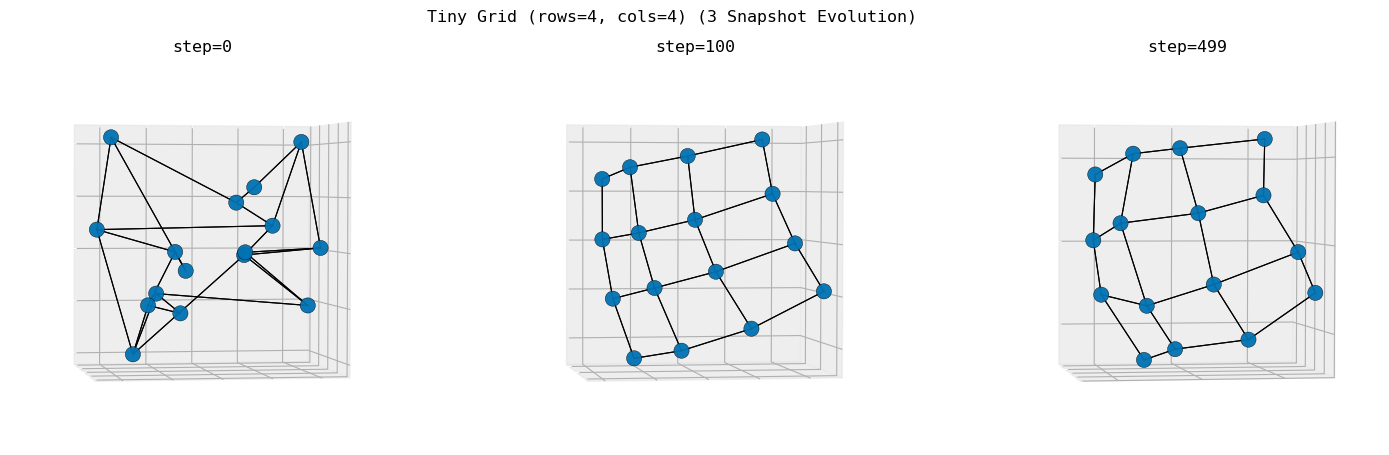

In [20]:
# Evolution constants for this block
grid_evolution_steps = [0, 100, 500]
grid_evolution_use_umap = False
grid_evolution_reduction_dim = 3
grid_evolution_umap_n_neighbors = 4
grid_evolution_umap_min_dist = 0.3
grid_evolution_view = {"elev": grid_raw_elev, "azim": grid_raw_azim, "roll": grid_raw_roll}
grid_evolution_axis_permutation = (0, 1, 2)

grid_resolved_evolution_steps, grid_reduced_evolution = build_reduced_evolution_snapshots(
    grid_embedding_history,
    selected_steps=grid_evolution_steps,
    use_umap=grid_evolution_use_umap,
    reduction_dim=grid_evolution_reduction_dim,
    seed=grid_seed,
    umap_n_neighbors=grid_evolution_umap_n_neighbors,
    umap_min_dist=grid_evolution_umap_min_dist,
)

print("Requested evolution steps:", grid_evolution_steps)
print("Resolved evolution steps:", grid_resolved_evolution_steps)

plot_three_snapshot_evolution(
    grid_reduced_evolution,
    grid_edge_list,
    title="Tiny Grid (rows=4, cols=4) (3 Snapshot Evolution)",
    view=grid_evolution_view,
    axis_permutation=grid_evolution_axis_permutation,
);


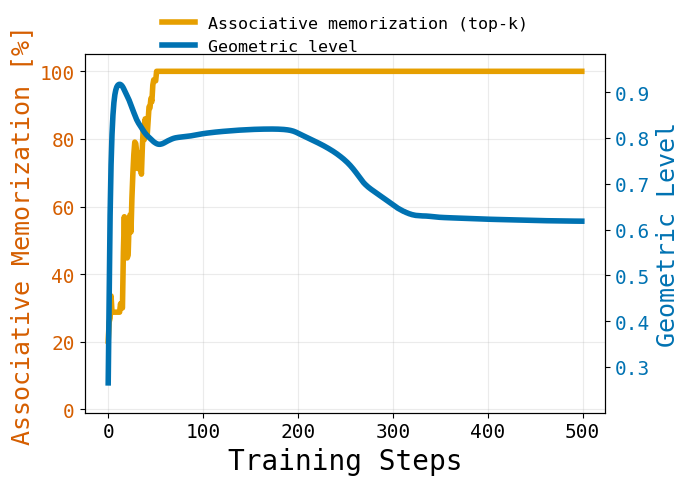

In [21]:
# Line-plot constants for this block
grid_line_plot_title = ""

grid_curve_steps, grid_curve_associative, grid_curve_geometric = compute_associative_geometric_curves(
    grid_embedding_history,
    grid_topk_recovery_history,
    grid_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=grid_curve_steps,
    associative_scores=grid_curve_associative,
    geometric_scores=grid_curve_geometric,
    title=grid_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `grid_heatmap_epoch` to one of the highest geometric_level epochs.

Grid heatmap epoch: 100
Grid heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14 15


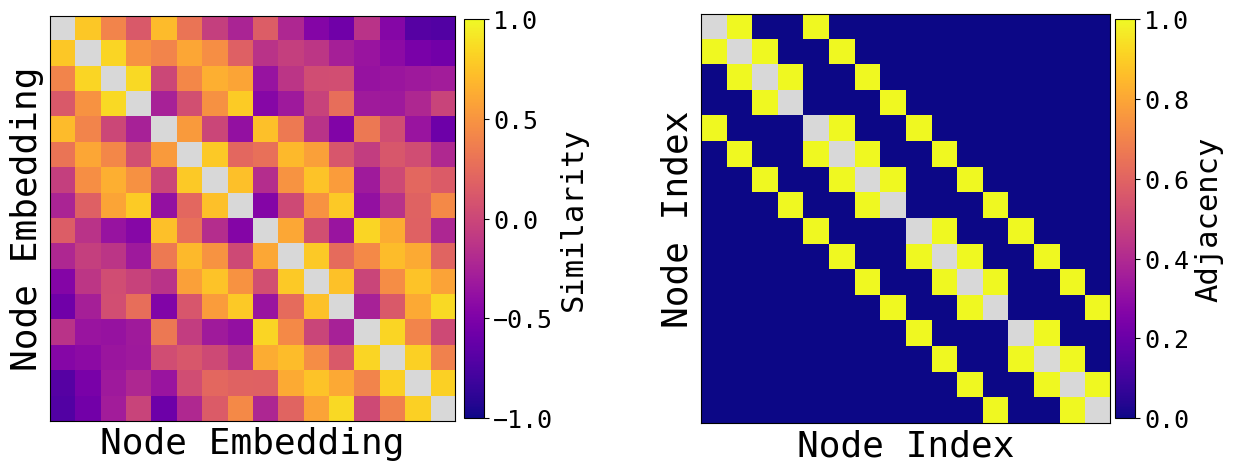

In [22]:
# Heatmap constants for this block
grid_heatmap_graph_type = grid_context.args.graph_type
grid_heatmap_epoch = 100
grid_heatmap_cmap_name = "plasma"
grid_heatmap_wspace = 0.5

grid_heatmap_embeddings, grid_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=grid_embedding_history,
    fallback_embeddings=grid_node_embeddings,
    requested_step=grid_heatmap_epoch,
)
print("Grid heatmap epoch:", grid_heatmap_resolved_epoch)
grid_heatmap_order = list(range(grid_heatmap_embeddings.shape[0]))
print("Grid heatmap order rows:")
for row_start in range(0, len(grid_heatmap_order), 4):
    row = grid_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=grid_heatmap_embeddings,
    edge_list=grid_edge_list,
    graph_type=grid_heatmap_graph_type,
    root_node_index=grid_root_node_index,
    custom_order=grid_heatmap_order,
    cmap_name=grid_heatmap_cmap_name,
    wspace=grid_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [23]:
# Laplacian geometry constants for this block
grid_laplacian_axis_indices = (-2, -3, -4)
grid_spectral_state = build_graph_spectral_state(
    edge_list=grid_edge_list,
    node_count=grid_node_embeddings.shape[0],
)

Grid normalized eigenvalues:
 [ 1.     1.     0.772  0.592  0.592  0.333  0.333  0.266  0.266 -0.
 -0.001 -0.084 -0.376 -0.376 -0.613]


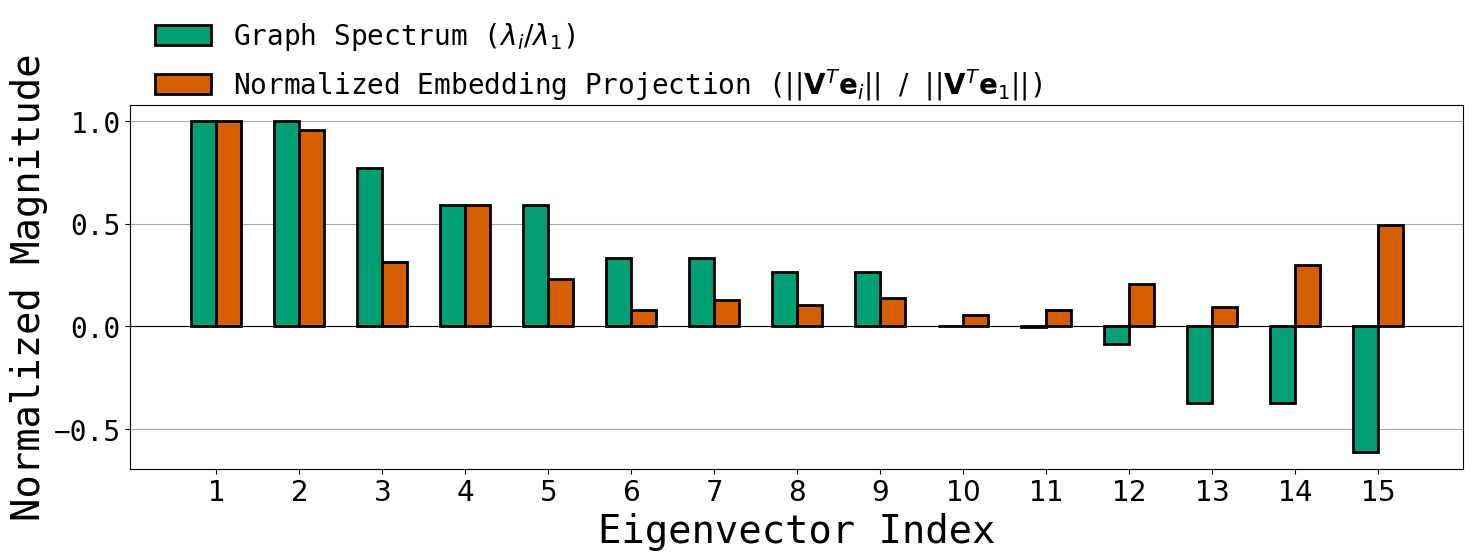

In [24]:
# Spectral-bias constants for this block
grid_spectral_drop_top_eigenvector = True
grid_spectral_reorder_prefix = None
grid_spectral_cutoff = None
grid_spectral_figsize = (15.0, 6.0)
grid_spectral_legend_anchor = (0.0, 1.3)

grid_norm_eigenvalues, grid_norm_projections = compute_spectral_bias_from_state(
    embeddings=grid_node_embeddings,
    spectral_state=grid_spectral_state,
    drop_top_eigenvector=grid_spectral_drop_top_eigenvector,
    reorder_prefix=grid_spectral_reorder_prefix,
)

print("Grid normalized eigenvalues:\n", grid_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=grid_norm_eigenvalues,
    norm_projections=grid_norm_projections,
    title="",
    cutoff=grid_spectral_cutoff,
    figsize=grid_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=grid_spectral_legend_anchor,
    save=True,
    filename=f"{grid_context.args.graph_type}_{grid_context.args.model_architecture_label}_eigen_projection"
);


## 3) Tiny Cycle (N=15)


In [25]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_laplacian_coordinates,
    compute_spectral_bias_from_state,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_spectral_bias,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [26]:
cycle_seed = 7

cycle_train_from_scratch = False
cycle_checkpoint_path = ""
cycle_embedding_history_path = ""
cycle_topk_history_path = ""
cycle_dataset_overwrite = False

cycle_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.01,
    "--edge_memorization_epochs": 700,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0.0,
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0.,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": True,
}


In [27]:
cycle_context = build_transformer_section_context(
    cycle_cli_config,
    seed=cycle_seed,
    dataset_overwrite=cycle_dataset_overwrite,
)

cycle_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_context,
    train_from_scratch=cycle_train_from_scratch,
    checkpoint_path=cycle_checkpoint_path,
)

print("Run name:", cycle_context.args.run_name)
print("Checkpoint:", cycle_resolved_checkpoint_path)
print("Pretrain file:", cycle_context.pretrain_path)
print("Train file:", cycle_context.train_path)
print("Test file:", cycle_context.test_path)
print("Archived checkpoint:", cycle_context.checkpoint_path)
print("Embedding history pickle:", cycle_context.embedding_history_path)
print("Top-k pickle:", cycle_context.topk_history_path)
print("Manifest:", cycle_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

In [28]:
cycle_eval_metrics = evaluate_edge_and_path(cycle_context)

print_evaluation_report("Tiny Cycle", cycle_eval_metrics)


Edge Memorization | Loss: 1.1051 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 86.51it/s]


Edge Memorization | Loss: 1.1051 | Acc: 33.33%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 96.35it/s]

Tiny Cycle | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [29]:
cycle_node_embeddings, cycle_edge_list, cycle_root_node_index = collect_embeddings_and_edges(cycle_context)

cycle_embedding_history, cycle_topk_recovery_history = load_analysis_histories(
    cycle_context,
    cycle_edge_list,
    embedding_history_path=cycle_embedding_history_path,
    topk_history_path=cycle_topk_history_path,
)

if not cycle_embedding_history:
    cycle_embedding_history = {0: cycle_node_embeddings}
if not cycle_topk_recovery_history:
    cycle_topk_recovery_history = {0: cycle_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_node_embeddings.shape)
print("Number of edges:", len(cycle_edge_list))
print("Root node index:", cycle_root_node_index)
print("Embedding history steps:", len(cycle_embedding_history))
print("Top-k history steps:", len(cycle_topk_recovery_history))


Node embedding shape: (15, 32)
Number of edges: 45
Root node index: None
Embedding history steps: 700
Top-k history steps: 700


In [30]:
# Reduction config for this block (kept local to reduction stage)
cycle_use_umap = False
cycle_reduction_dim = 4
cycle_umap_n_neighbors = 8
cycle_umap_min_dist = 0.3

cycle_reduced_full, cycle_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_node_embeddings,
    use_umap=cycle_use_umap,
    reduction_dim=cycle_reduction_dim,
    seed=cycle_seed,
    umap_n_neighbors=cycle_umap_n_neighbors,
    umap_min_dist=cycle_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_reduced_embeddings = cycle_reduced_full[:, :3]
print("Reduced full shape:", cycle_reduced_full.shape)
print("Reduced xyz shape:", cycle_reduced_embeddings.shape)


Reduced full shape: (15, 4)
Reduced xyz shape: (15, 3)


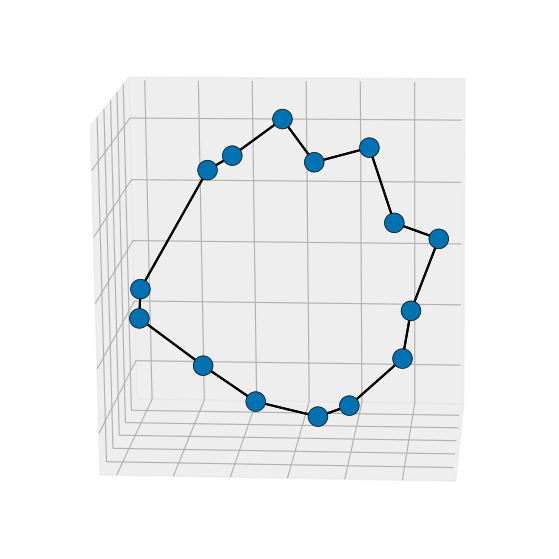

In [31]:
%matplotlib inline
# %matplotlib widget

cycle_raw_elev = 75
cycle_raw_azim = 70
cycle_raw_roll = 160

# Styled plotting constants for this block
cycle_styled_view = {"elev": cycle_raw_elev, "azim": cycle_raw_azim, "roll": cycle_raw_roll}
cycle_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_reduced_embeddings,
    cycle_edge_list,
    title="",
    view=cycle_styled_view,
    root_node_index=cycle_root_node_index,
    axis_permutation=cycle_styled_axis_permutation,
);


/home/snoroozi/anaconda3/envs/geometric_memory/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Requested evolution steps: [0, 250, 500]
Resolved evolution steps: [0, 250, 500]


/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/analysis/analysis_plots.py:139: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


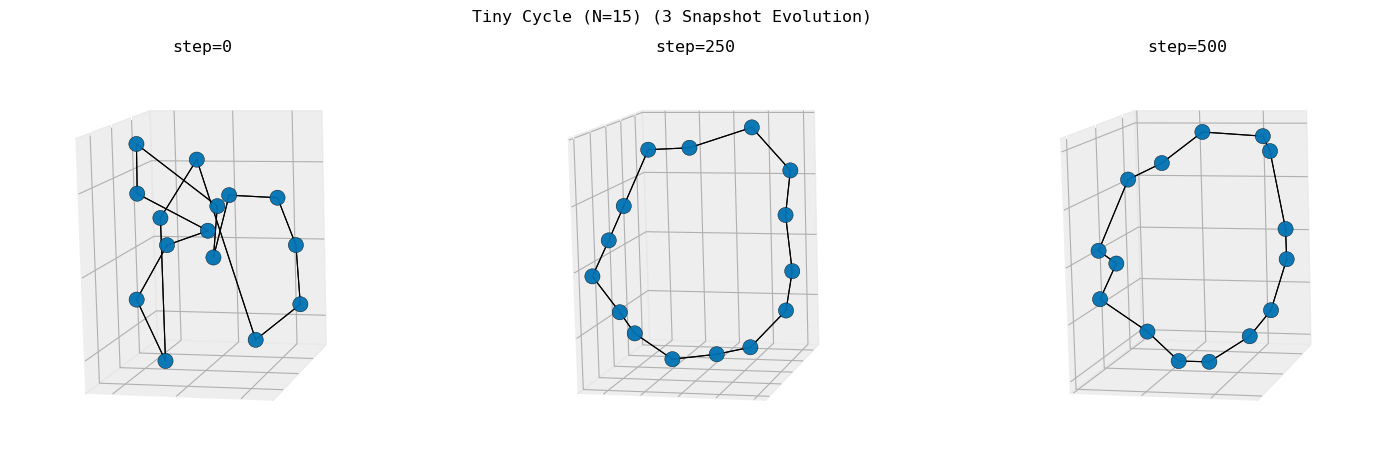

In [32]:
# Evolution constants for this block
cycle_evolution_steps = [0, 250, 500]
cycle_evolution_use_umap = True
cycle_evolution_reduction_dim = 3
cycle_evolution_umap_n_neighbors = 8
cycle_evolution_umap_min_dist = 0.3
cycle_evolution_view = {"elev": cycle_raw_elev-60, "azim": cycle_raw_azim+100, "roll": cycle_raw_roll+109}
cycle_evolution_axis_permutation = (0, 2, 1)

cycle_resolved_evolution_steps, cycle_reduced_evolution = build_reduced_evolution_snapshots(
    cycle_embedding_history,
    selected_steps=cycle_evolution_steps,
    use_umap=cycle_evolution_use_umap,
    reduction_dim=cycle_evolution_reduction_dim,
    seed=cycle_seed,
    umap_n_neighbors=cycle_evolution_umap_n_neighbors,
    umap_min_dist=cycle_evolution_umap_min_dist,
)

print("Requested evolution steps:", cycle_evolution_steps)
print("Resolved evolution steps:", cycle_resolved_evolution_steps)

plot_three_snapshot_evolution(
    cycle_reduced_evolution,
    cycle_edge_list,
    title="Tiny Cycle (N=15) (3 Snapshot Evolution)",
    view=cycle_evolution_view,
    axis_permutation=cycle_evolution_axis_permutation,
);


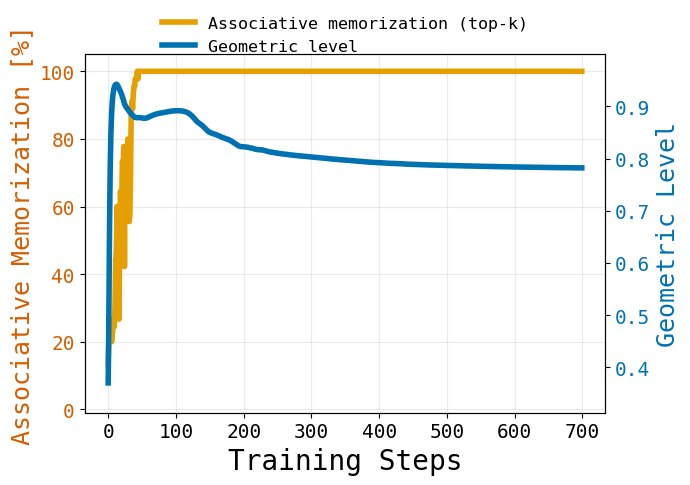

In [33]:
# Line-plot constants for this block
cycle_line_plot_title = ""

cycle_curve_steps, cycle_curve_associative, cycle_curve_geometric = compute_associative_geometric_curves(
    cycle_embedding_history,
    cycle_topk_recovery_history,
    cycle_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_curve_steps,
    associative_scores=cycle_curve_associative,
    geometric_scores=cycle_curve_geometric,
    title=cycle_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `cycle_heatmap_epoch` to one of the highest geometric_level epochs.

Cycle heatmap epoch: 250
Irregular heatmap order:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14


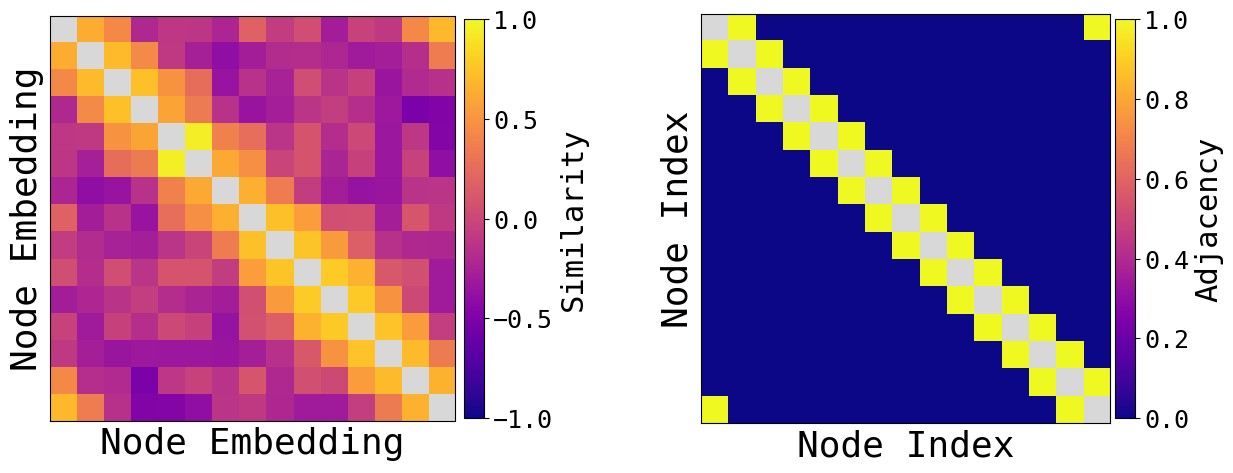

In [34]:
# Heatmap constants for this block
cycle_heatmap_graph_type = cycle_context.args.graph_type
cycle_heatmap_epoch = 250
cycle_heatmap_cmap_name = "plasma"
cycle_heatmap_wspace = 0.5

cycle_heatmap_embeddings, cycle_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_embedding_history,
    fallback_embeddings=cycle_node_embeddings,
    requested_step=cycle_heatmap_epoch,
)
print("Cycle heatmap epoch:", cycle_heatmap_resolved_epoch)
cycle_heatmap_order = list(range(cycle_heatmap_embeddings.shape[0]))
print("Irregular heatmap order:")
print(" ".join(str(node_id) for node_id in cycle_heatmap_order))

plot_ordered_heatmaps(
    embeddings=cycle_heatmap_embeddings,
    edge_list=cycle_edge_list,
    graph_type=cycle_heatmap_graph_type,
    root_node_index=cycle_root_node_index,
    custom_order=cycle_heatmap_order,
    cmap_name=cycle_heatmap_cmap_name,
    wspace=cycle_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [35]:
# Laplacian geometry constants for this block
cycle_laplacian_axis_indices = (-2, -3, -4)
cycle_spectral_state = build_graph_spectral_state(
    edge_list=cycle_edge_list,
    node_count=cycle_node_embeddings.shape[0],
)


Cycle normalized eigenvalues:
 [ 1.     1.     0.827  0.827  0.572  0.572  0.28   0.28   0.    -0.
 -0.219 -0.219 -0.338 -0.338]


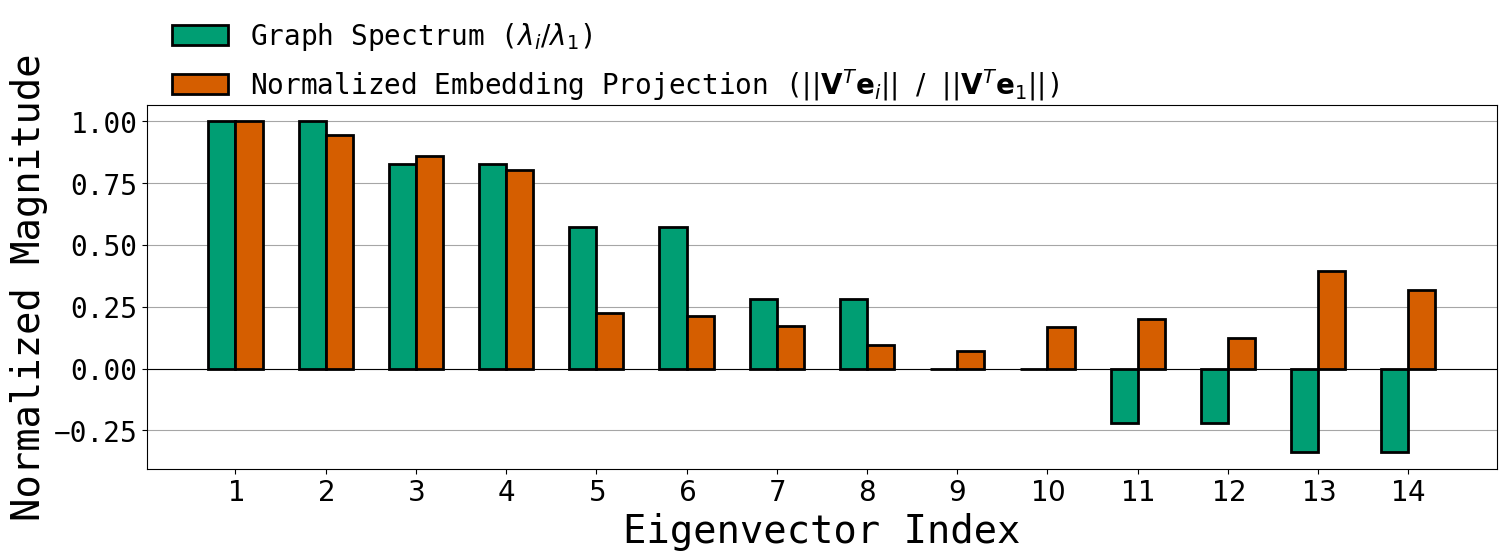

In [36]:
# Spectral-bias constants for this block
cycle_spectral_drop_top_eigenvector = True
cycle_spectral_reorder_prefix = None
cycle_spectral_cutoff = None
cycle_spectral_figsize = (15.0, 6.0)
cycle_spectral_legend_anchor = (0.0, 1.3)

cycle_norm_eigenvalues, cycle_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_node_embeddings,
    spectral_state=cycle_spectral_state,
    drop_top_eigenvector=cycle_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_spectral_reorder_prefix,
)

print("Cycle normalized eigenvalues:\n", cycle_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=cycle_norm_eigenvalues,
    norm_projections=cycle_norm_projections,
    title="",
    cutoff=cycle_spectral_cutoff,
    figsize=cycle_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_spectral_legend_anchor,
    save=True,
    filename=f"{cycle_context.args.graph_type}_{cycle_context.args.model_family}_eigen_projection"
);


## 4) Tiny Irregular (N=16, Fixed Edge List)


In [37]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_laplacian_coordinates,
    compute_spectral_bias_from_state,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_spectral_bias,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [38]:
irregular_seed = 7

irregular_train_from_scratch = False
irregular_checkpoint_path = ""
irregular_embedding_history_path = ""
irregular_topk_history_path = ""
irregular_dataset_overwrite = False

irregular_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.01,
    "--edge_memorization_epochs": 2000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 48,
    "--optimizer_weight_decay": 0.0,
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0.,

    "--graph_type": "irregular",
    "--path_length": 5,
    "--total_nodes": 16,
    "--irregular_edge_count": 20,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": True,
}


In [39]:
irregular_context = build_transformer_section_context(
    irregular_cli_config,
    seed=irregular_seed,
    dataset_overwrite=irregular_dataset_overwrite,
)

irregular_resolved_checkpoint_path = train_or_load_edge_model(
    irregular_context,
    train_from_scratch=irregular_train_from_scratch,
    checkpoint_path=irregular_checkpoint_path,
)

print("Run name:", irregular_context.args.run_name)
print("Checkpoint:", irregular_resolved_checkpoint_path)
print("Pretrain file:", irregular_context.pretrain_path)
print("Train file:", irregular_context.train_path)
print("Test file:", irregular_context.test_path)
print("Archived checkpoint:", irregular_context.checkpoint_path)
print("Embedding history pickle:", irregular_context.embedding_history_path)
print("Top-k pickle:", irregular_context.topk_history_path)
print("Manifest:", irregular_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_selfedge_0_train_12.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geome

In [40]:
irregular_eval_metrics = evaluate_edge_and_path(irregular_context)

print_evaluation_report("Tiny Irregular", irregular_eval_metrics)


Edge Memorization | Loss: 1.2645 | Acc: 28.57%: 100%|██████████| 1/1 [00:00<00:00, 65.39it/s]


Edge Memorization | Loss: 1.2645 | Acc: 28.57%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 80.70it/s]

Tiny Irregular | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [41]:
irregular_node_embeddings, irregular_edge_list, irregular_root_node_index = collect_embeddings_and_edges(irregular_context)

irregular_embedding_history, irregular_topk_recovery_history = load_analysis_histories(
    irregular_context,
    irregular_edge_list,
    embedding_history_path=irregular_embedding_history_path,
    topk_history_path=irregular_topk_history_path,
)

if not irregular_embedding_history:
    irregular_embedding_history = {0: irregular_node_embeddings}
if not irregular_topk_recovery_history:
    irregular_topk_recovery_history = {0: irregular_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", irregular_node_embeddings.shape)
print("Number of edges:", len(irregular_edge_list))
print("Root node index:", irregular_root_node_index)
print("Embedding history steps:", len(irregular_embedding_history))
print("Top-k history steps:", len(irregular_topk_recovery_history))


Node embedding shape: (16, 48)
Number of edges: 56
Root node index: None
Embedding history steps: 2000
Top-k history steps: 2000


In [42]:
# Reduction config for this block (kept local to reduction stage)
irregular_use_umap = False
irregular_reduction_dim = 4
irregular_umap_n_neighbors = 8
irregular_umap_min_dist = 0.3

irregular_reduced_full, irregular_reduced_embeddings = reduce_embeddings_for_plot(
    irregular_node_embeddings,
    use_umap=irregular_use_umap,
    reduction_dim=irregular_reduction_dim,
    seed=irregular_seed,
    umap_n_neighbors=irregular_umap_n_neighbors,
    umap_min_dist=irregular_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
irregular_reduced_embeddings = irregular_reduced_full[:, :3]
print("Reduced full shape:", irregular_reduced_full.shape)
print("Reduced xyz shape:", irregular_reduced_embeddings.shape)


Reduced full shape: (16, 4)
Reduced xyz shape: (16, 3)


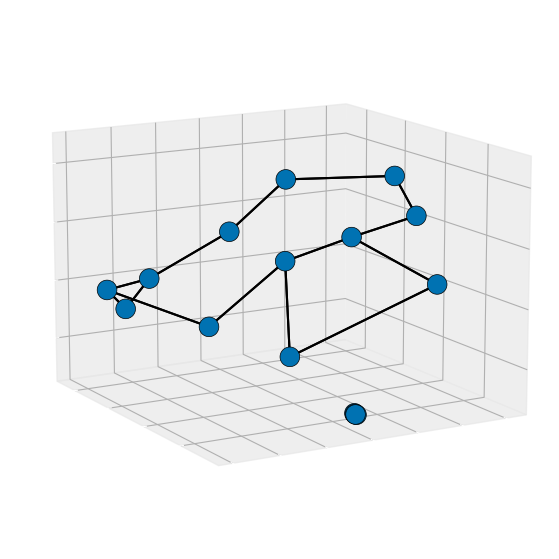

In [43]:
%matplotlib inline
# %matplotlib widget

irregular_raw_elev = 13
irregular_raw_azim = 60
irregular_raw_roll = 0

# Styled plotting constants for this block
irregular_styled_view = {"elev": irregular_raw_elev, "azim": irregular_raw_azim, "roll": irregular_raw_roll}
irregular_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    irregular_reduced_embeddings,
    irregular_edge_list,
    title="",
    view=irregular_styled_view,
    root_node_index=irregular_root_node_index,
    axis_permutation=irregular_styled_axis_permutation,
);


Requested evolution steps: [0, 40, 500]
Resolved evolution steps: [0, 40, 500]


/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/analysis/analysis_plots.py:139: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


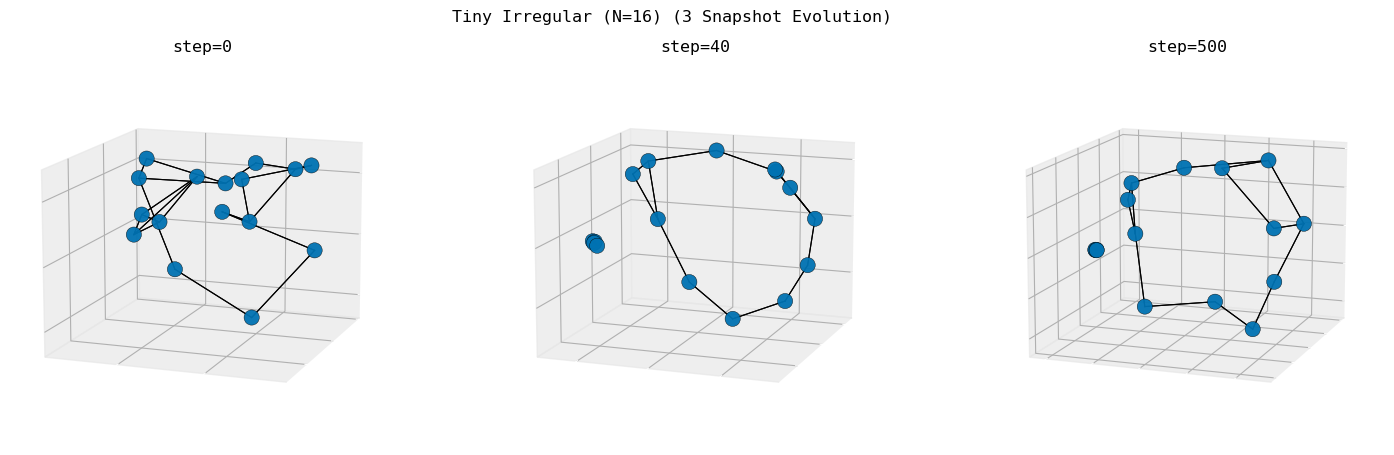

In [44]:
# Evolution constants for this block
irregular_evolution_steps = [0, 40, 500]
irregular_evolution_use_umap = False
irregular_evolution_reduction_dim = 3
irregular_evolution_umap_n_neighbors = 8
irregular_evolution_umap_min_dist = 0.3
irregular_evolution_view = {"elev": irregular_raw_elev, "azim": irregular_raw_azim+50, "roll": irregular_raw_roll}
irregular_evolution_axis_permutation = (0, 1, 2)

irregular_resolved_evolution_steps, irregular_reduced_evolution = build_reduced_evolution_snapshots(
    irregular_embedding_history,
    selected_steps=irregular_evolution_steps,
    use_umap=irregular_evolution_use_umap,
    reduction_dim=irregular_evolution_reduction_dim,
    seed=irregular_seed,
    umap_n_neighbors=irregular_evolution_umap_n_neighbors,
    umap_min_dist=irregular_evolution_umap_min_dist,
)

print("Requested evolution steps:", irregular_evolution_steps)
print("Resolved evolution steps:", irregular_resolved_evolution_steps)

plot_three_snapshot_evolution(
    irregular_reduced_evolution,
    irregular_edge_list,
    title="Tiny Irregular (N=16) (3 Snapshot Evolution)",
    view=irregular_evolution_view,
    axis_permutation=irregular_evolution_axis_permutation,
);


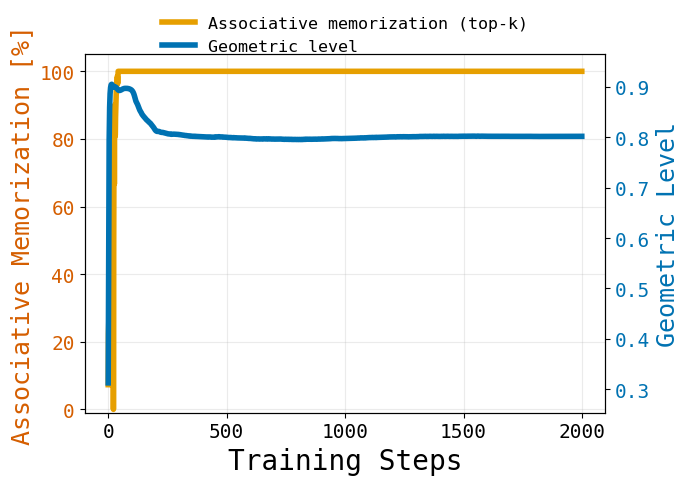

In [45]:
# Line-plot constants for this block
irregular_line_plot_title = ""

irregular_curve_steps, irregular_curve_associative, irregular_curve_geometric = compute_associative_geometric_curves(
    irregular_embedding_history,
    irregular_topk_recovery_history,
    irregular_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=irregular_curve_steps,
    associative_scores=irregular_curve_associative,
    geometric_scores=irregular_curve_geometric,
    title=irregular_line_plot_title,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

Note setting `irregular_heatmap_epoch` to one of the highest geometric_level epochs.

Irregular heatmap epoch: 40
Irregular heatmap order:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15


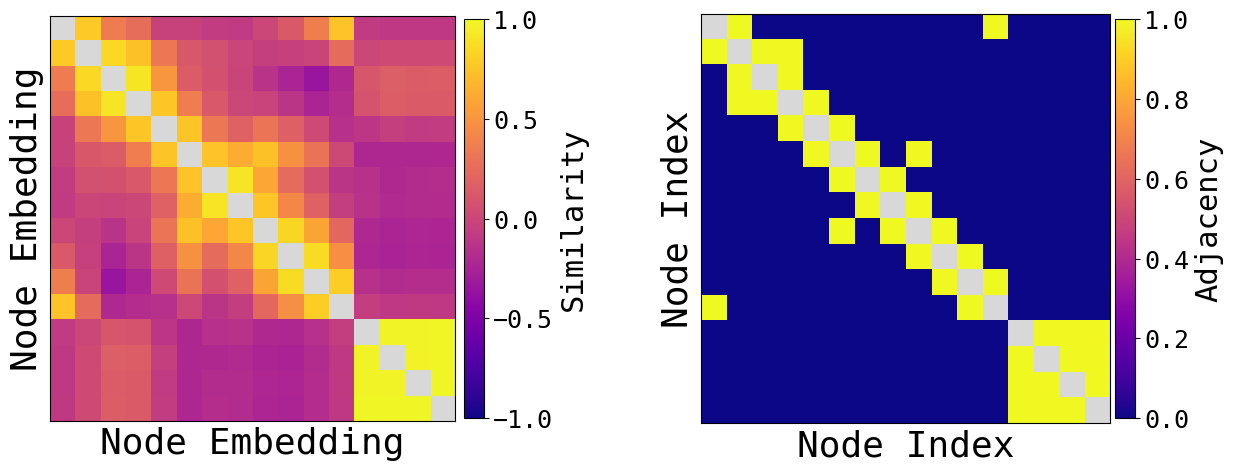

In [46]:
# Heatmap constants for this block
irregular_heatmap_graph_type = irregular_context.args.graph_type
irregular_heatmap_epoch = 40
irregular_heatmap_cmap_name = "plasma"
irregular_heatmap_wspace = 0.5

irregular_heatmap_embeddings, irregular_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=irregular_embedding_history,
    fallback_embeddings=irregular_node_embeddings,
    requested_step=irregular_heatmap_epoch,
)
print("Irregular heatmap epoch:", irregular_heatmap_resolved_epoch)
irregular_heatmap_order = list(range(irregular_heatmap_embeddings.shape[0]))
print("Irregular heatmap order:")
print(" ".join(str(node_id) for node_id in irregular_heatmap_order))

plot_ordered_heatmaps(
    embeddings=irregular_heatmap_embeddings,
    edge_list=irregular_edge_list,
    graph_type=irregular_heatmap_graph_type,
    root_node_index=irregular_root_node_index,
    custom_order=irregular_heatmap_order,
    cmap_name=irregular_heatmap_cmap_name,
    wspace=irregular_heatmap_wspace,
);


### Skewed Low-Rank Spectral Bias


In [47]:
# Laplacian geometry constants for this block
irregular_laplacian_axis_indices = (-2, -3, -4)
irregular_spectral_state = build_graph_spectral_state(
    edge_list=irregular_edge_list,
    node_count=irregular_node_embeddings.shape[0],
)


Irregular normalized eigenvalues:
 [ 1.     0.917  0.859  0.601  0.535  0.333  0.195  0.096  0.     0.
 -0.    -0.09  -0.127 -0.273 -0.384]


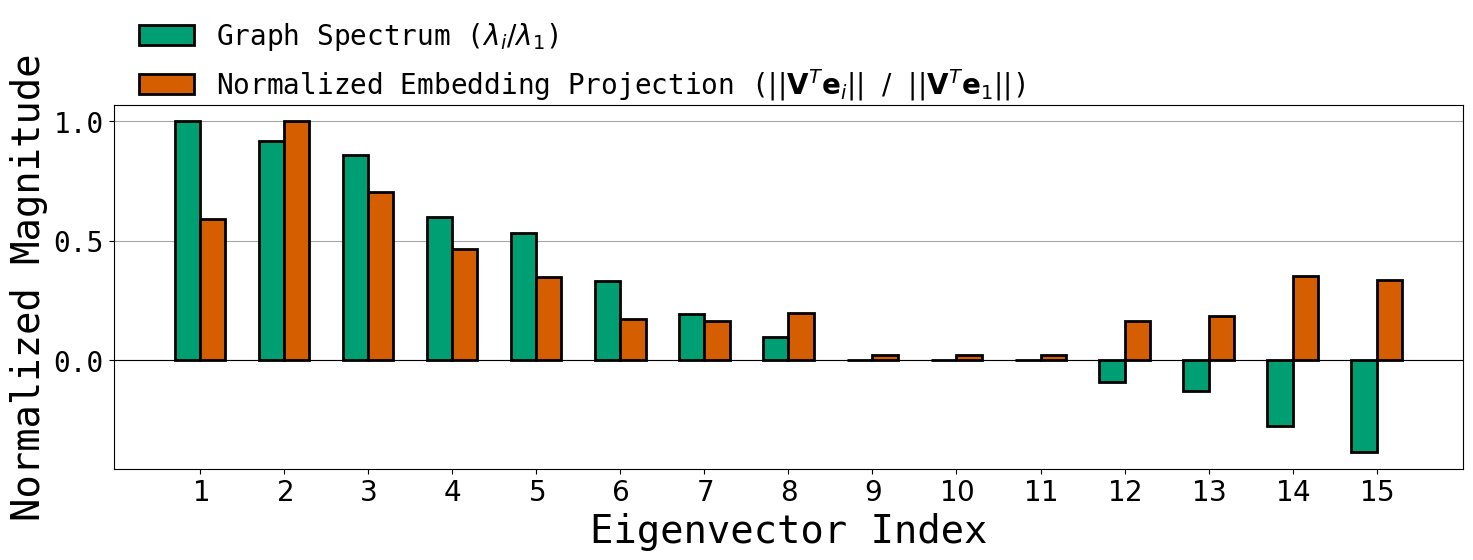

In [48]:
# Spectral-bias constants for this block
irregular_spectral_drop_top_eigenvector = True
irregular_spectral_reorder_prefix = None
irregular_spectral_cutoff = None
irregular_spectral_figsize = (15.0, 6.0)
irregular_spectral_legend_anchor = (0.0, 1.3)

irregular_norm_eigenvalues, irregular_norm_projections = compute_spectral_bias_from_state(
    embeddings=irregular_node_embeddings,
    spectral_state=irregular_spectral_state,
    drop_top_eigenvector=irregular_spectral_drop_top_eigenvector,
    reorder_prefix=irregular_spectral_reorder_prefix,
)

print("Irregular normalized eigenvalues:\n", irregular_norm_eigenvalues.round(3))

plot_spectral_bias(
    norm_eigenvalues=irregular_norm_eigenvalues,
    norm_projections=irregular_norm_projections,
    title="",
    cutoff=irregular_spectral_cutoff,
    figsize=irregular_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=irregular_spectral_legend_anchor,
    save=True,
    filename=f"{irregular_context.args.graph_type}_{irregular_context.args.model_family}_eigen_projection"
);
